# 1.1. Clasification multiclass

## Data curation

### Data loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def read_data(file_path):
    data = pd.read_csv(file_path, sep=';', decimal=',')
    data['Fecha'] = pd.to_datetime(data['Fecha'], format='%d/%m/%Y %H:%M')
    grid_mapping = {
        '0': 0,
        'A1': 1,
        'A2': 4,
        'A3': 7,
        'B1': 2,
        'B2': 5,
        'B3': 8,
        'C1': 3,
        'C2': 6,
        'C3': 9
    }
    data['Cuadricula'] = data['Cuadricula'].map(grid_mapping)
    return data

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
filepath='1_RMS_600.csv'

In [29]:
data = read_data(filepath)
data = data.drop(['Peso', 'Fecha'], axis=1)

In [30]:
data.tail()

,Cuadricula,Sigma0,Sigma1,Sigma2,Sigma3,Sigma4,Sigma5,Sigma6,Sigma7,Sigma8,...,Sigma14,Sigma15,Sigma16,Sigma17,Sigma18,Sigma19,Sigma20,Sigma21,Sigma22,Sigma23
987,9,0.023283,0.009585,0.031363,0.029732,0.009806,0.012722,0.009035,0.010135,0.012429,...,0.008799,0.016818,0.008185,0.004663,0.006774,0.007621,0.007948,0.009949,0.007657,0.007385
988,9,0.023185,0.009551,0.031064,0.029578,0.009770,0.012632,0.009026,0.010094,0.012449,...,0.008972,0.016721,0.008142,0.004726,0.006722,0.007583,0.008099,0.009865,0.007622,0.007495
989,9,0.024112,0.009871,0.031116,0.030829,0.010112,0.012660,0.009308,0.010451,0.012505,...,0.006015,0.016639,0.008232,0.004075,0.006766,0.007671,0.006004,0.009889,0.007712,0.004766
990,9,0.024985,0.010174,0.030469,0.032039,0.010421,0.012543,0.009625,0.010775,0.012378,...,0.008892,0.017777,0.008715,0.005149,0.007123,0.008117,0.007975,0.010539,0.008146,0.007365
991,9,0.023702,0.009752,0.029451,0.030291,0.009986,0.012293,0.009203,0.010315,0.012219,...,0.008790,0.016654,0.008197,0.005183,0.006756,0.007644,0.007929,0.009873,0.007676,0.007285


### Data splitting

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [32]:
test_size = 0.2
validation_size = 0.25

In [33]:
X = data.drop('Cuadricula', axis=1)  # Features (input columns)
y = data['Cuadricula']  # Labels (target column)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

# Further split train into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=validation_size, random_state=42, stratify=y_train)

### Standarization

In [34]:
# Create a StandardScaler object
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the validation and test data using the fitted scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [35]:
columns_to_normalize = [f'Sigma{i}' for i in range(24)]  # Create a list of columns

# Normalize by dividing each value by the row's maximum
X_train_scaled = X_train[columns_to_normalize].div(X_train[columns_to_normalize].max(axis=1), axis=0)
X_val_scaled = X_val[columns_to_normalize].div(X_val[columns_to_normalize].max(axis=1), axis=0)
X_test_scaled = X_test[columns_to_normalize].div(X_test[columns_to_normalize].max(axis=1), axis=0)

## SVM

In [36]:
from sklearn.svm import SVC
from scipy.stats import uniform, randint
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

### Naive approach

In [37]:
# Create an SVM classifier
svm_model = SVC(kernel='linear')  # You can choose different kernels like 'rbf', 'poly', etc.

# Train the model
svm_model.fit(X_train_scaled, y_train)

SVC(kernel='linear')

### Test data

In [38]:
# Make predictions on the test set
y_pred_test = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        18
           5       1.00      1.00      1.00        21
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20

    accuracy                           1.00       199
   macro avg       1.00      1.00      1.00       199
weighted avg       1.00      1.00      1.00       199



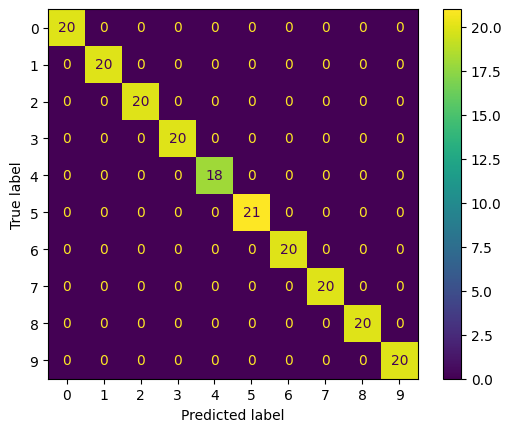

In [39]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot()
plt.show()

### Model testing

In [40]:
datos_prueba = read_data('/content/drive/MyDrive/D1/1_RMS_validation_C2.csv')

In [41]:
schedule = [
    {'start_date': pd.to_datetime('2025-01-23 12:34:00'), 'end_date': pd.to_datetime('2025-01-23 13:00:00'), 'Vpp': 2, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-23 13:00:00'), 'end_date': pd.to_datetime('2025-01-23 13:30:00'), 'Vpp': 1, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-23 13:30:00'), 'end_date': pd.to_datetime('2025-01-23 14:20:00'), 'Vpp': 0.5, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-23 14:21:00'), 'end_date': pd.to_datetime('2025-01-23 15:15:00'), 'Vpp': 0.25, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-23 15:15:00'), 'end_date': pd.to_datetime('2025-01-24 00:22:00'), 'Vpp': 0.125, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-24 00:22:00'), 'end_date': pd.to_datetime('2025-01-24 15:00:00'), 'Vpp': 0.0625, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-24 16:00:00'), 'end_date': pd.to_datetime('2025-01-24 18:00:00'), 'Vpp': 1, 'Hz': 60},
    {'start_date': pd.to_datetime('2025-01-24 18:00:00'), 'end_date': pd.to_datetime('2025-01-25 02:00:00'), 'Vpp': 1, 'Hz': 20},
    {'start_date': pd.to_datetime('2025-01-25 02:00:00'), 'end_date': pd.to_datetime('2025-01-25 09:50:00'), 'Vpp': 1, 'Hz': 10},
    {'start_date': pd.to_datetime('2025-01-25 10:00:00'), 'end_date': pd.to_datetime('2025-01-25 12:30:00'), 'Vpp': 1, 'Hz': 5},
    {'start_date': pd.to_datetime('2025-01-25 12:30:00'), 'end_date': pd.to_datetime('2025-01-25 15:00:00'), 'Vpp': 1, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-25 15:00:00'), 'end_date': pd.to_datetime('2025-01-25 16:00:00'), 'Vpp': 1, 'Hz': 15},
    {'start_date': pd.to_datetime('2025-01-25 16:00:00'), 'end_date': pd.to_datetime('2025-01-25 19:40:00'), 'Vpp': 1, 'Hz': 20},
    {'start_date': pd.to_datetime('2025-01-25 19:40:00'), 'end_date': pd.to_datetime('2025-01-26 00:30:00'), 'Vpp': 1, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-26 00:30:00'), 'end_date': pd.to_datetime('2025-01-26 19:00:00'), 'Vpp': 1, 'Hz': 40},
    {'start_date': pd.to_datetime('2025-01-26 19:30:00'), 'end_date': pd.to_datetime('2025-01-26 23:05:00'), 'Vpp': 1, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-26 23:30:00'), 'end_date': pd.to_datetime('2025-01-27 03:00:00'), 'Vpp': 1, 'Hz': 20},
    {'start_date': pd.to_datetime('2025-01-27 03:15:00'), 'end_date': pd.to_datetime('2025-01-27 08:09:00'), 'Vpp': 1, 'Hz': 10},
    {'start_date': pd.to_datetime('2025-01-27 08:15:00'), 'end_date': pd.to_datetime('2025-01-27 16:15:00'), 'Vpp': 1, 'Hz': 5},
    {'start_date': pd.to_datetime('2025-01-27 16:15:00'), 'end_date': pd.to_datetime('2025-01-28 03:20:00'), 'Vpp': 1, 'Hz': 10},
    {'start_date': pd.to_datetime('2025-01-28 03:20:00'), 'end_date': pd.to_datetime('2025-01-28 08:30:00'), 'Vpp': 1, 'Hz': 20},
    {'start_date': pd.to_datetime('2025-01-28 08:30:00'), 'end_date': pd.to_datetime('2025-01-28 23:45:00'), 'Vpp': 1, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-28 23:45:00'), 'end_date': pd.to_datetime('2025-01-29 09:07:00'), 'Vpp': 0.75, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-29 09:07:00'), 'end_date': pd.to_datetime('2025-01-29 18:11:00'), 'Vpp': 0.5, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-29 18:11:00'), 'end_date': pd.to_datetime('2025-01-30 00:00:00'), 'Vpp': 0.25, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-30 00:00:00'), 'end_date': pd.to_datetime('2025-01-30 07:54:00'), 'Vpp': 0.125, 'Hz': 30},
    {'start_date': pd.to_datetime('2025-01-30 07:54:00'), 'end_date': pd.to_datetime('2025-01-30 14:00:00'), 'Vpp': 0.065, 'Hz': 30}
]

In [42]:
def assign_values(row):
    for entry in schedule:
        if entry['start_date'] <= row['Fecha'] < entry['end_date']:
            return entry['Vpp'], entry['Hz']
    return None, None  # Default values if not found in schedule

# Apply the function to create new columns
datos_prueba[['Vpp', 'Hz']] = datos_prueba.apply(assign_values, axis=1, result_type='expand')
datos_prueba = datos_prueba.dropna(subset=['Vpp', 'Hz'])

In [43]:
datos_prueba.tail()

,Cuadricula,Peso,Fecha,Sigma0,Sigma1,Sigma2,Sigma3,Sigma4,Sigma5,Sigma6,...,Sigma16,Sigma17,Sigma18,Sigma19,Sigma20,Sigma21,Sigma22,Sigma23,Vpp,Hz
242,6,100,2025-01-30 11:30:00,0.002002,0.001193,0.002658,0.002434,0.001203,0.002485,0.001236,...,0.001164,0.001953,0.001221,0.001152,0.002890,0.001215,0.001133,0.002364,0.065,30.0
243,6,100,2025-01-30 12:00:00,0.002059,0.001217,0.002768,0.002523,0.001226,0.002560,0.001268,...,0.001198,0.002412,0.001235,0.001171,0.004116,0.001235,0.001151,0.003915,0.065,30.0
244,6,100,2025-01-30 12:30:00,0.002058,0.001227,0.002708,0.002529,0.001226,0.002621,0.001286,...,0.001182,0.002757,0.001270,0.001172,0.002727,0.001247,0.001157,0.001966,0.065,30.0
245,6,100,2025-01-30 13:00:00,0.002108,0.001233,0.002738,0.002588,0.001237,0.002452,0.001269,...,0.001201,0.002250,0.001230,0.001175,0.003911,0.001242,0.001161,0.003674,0.065,30.0
246,6,100,2025-01-30 13:30:00,0.002046,0.001204,0.002645,0.002495,0.001210,0.002414,0.001241,...,0.001157,0.001807,0.001219,0.001162,0.002662,0.001227,0.001144,0.001834,0.065,30.0


In [44]:
X_prueba = datos_prueba.drop(['Peso', 'Fecha', 'Cuadricula', 'Vpp', 'Hz'], axis=1)  # Features (input columns)
y_prueba = datos_prueba['Cuadricula']  # Labels (target column)
labels_prueba = datos_prueba[['Vpp', 'Hz']]  # Labels (target column)

In [45]:
#X_prueba_scaled = scaler.transform(X_prueba)
X_prueba_scaled = X_prueba[columns_to_normalize].div(X_prueba[columns_to_normalize].max(axis=1), axis=0)

In [46]:
y_pred = svm_model.predict(X_prueba_scaled)
print(classification_report(y_prueba, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       1.00      0.41      0.58       245
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0

    accuracy                           0.41       245
   macro avg       0.17      0.07      0.10       245
weighted avg       1.00      0.41      0.58       245



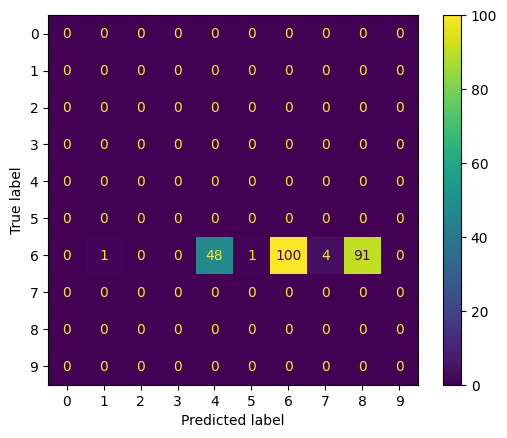

In [49]:
# Calculate confusion matrix
cm = confusion_matrix(y_prueba, y_pred, labels=svm_model.classes_)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot()
plt.show()

In [50]:
results_df = pd.DataFrame({'Vpp': labels_prueba['Vpp'],
                           'Hz': labels_prueba['Hz'],
                           'Actual_Class': y_prueba,
                           'Predicted_Class': y_pred})

In [51]:
# Group by 'Vpp' and 'Hz' and calculate accuracy
accuracy_by_vpp_hz = results_df.groupby(['Vpp', 'Hz'])['Actual_Class'].apply(lambda x: accuracy_score(x, results_df.loc[x.index, 'Predicted_Class']))

# Print the accuracy for each combination of 'Vpp' and 'Hz'
print(accuracy_by_vpp_hz)

# You can further analyze the results by looking at other metrics like precision, recall, etc.
# For example, to calculate precision for each group:
precision_by_vpp_hz = results_df.groupby(['Vpp', 'Hz'])['Actual_Class'].apply(lambda x: precision_score(x, results_df.loc[x.index, 'Predicted_Class'], average='weighted', zero_division=0))  # Use zero_division=0 to handle cases where a class is not predicted
print(precision_by_vpp_hz)

Vpp     Hz  
0.0625  30.0    0.000000
0.0650  30.0    0.000000
0.1250  30.0    0.000000
0.2500  30.0    0.000000
0.5000  30.0    0.555556
0.7500  30.0    0.894737
1.0000  5.0     0.052632
        10.0    0.000000
        15.0    0.000000
        20.0    0.892857
        30.0    0.977778
        40.0    0.125000
        60.0    0.000000
Name: Actual_Class, dtype: float64
Vpp     Hz  
0.0625  30.0    0.0
0.0650  30.0    0.0
0.1250  30.0    0.0
0.2500  30.0    0.0
0.5000  30.0    1.0
0.7500  30.0    1.0
1.0000  5.0     1.0
        10.0    0.0
        15.0    0.0
        20.0    1.0
        30.0    1.0
        40.0    1.0
        60.0    0.0
Name: Actual_Class, dtype: float64


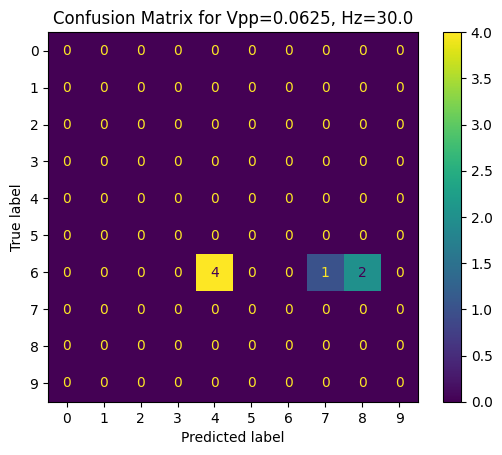

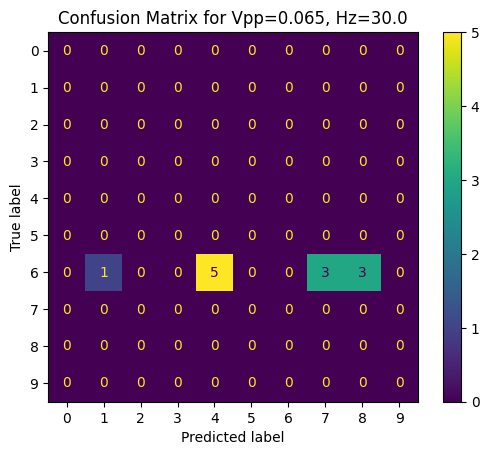

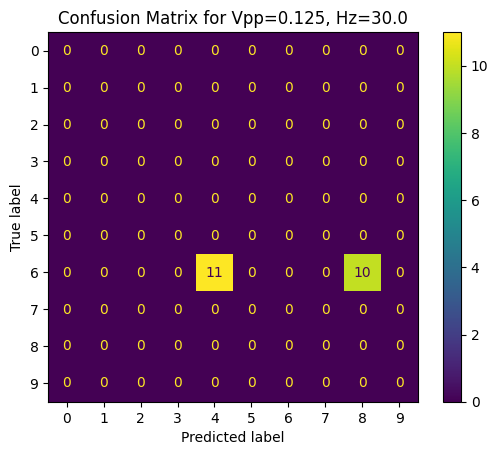

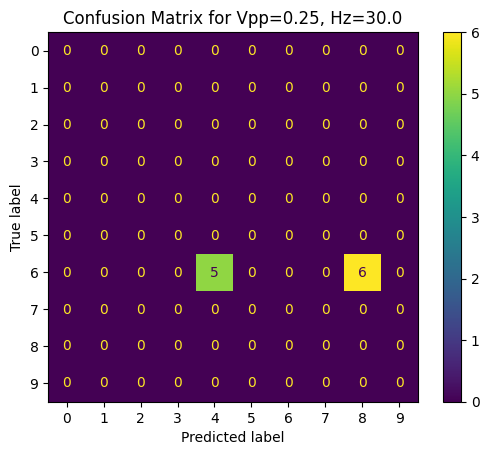

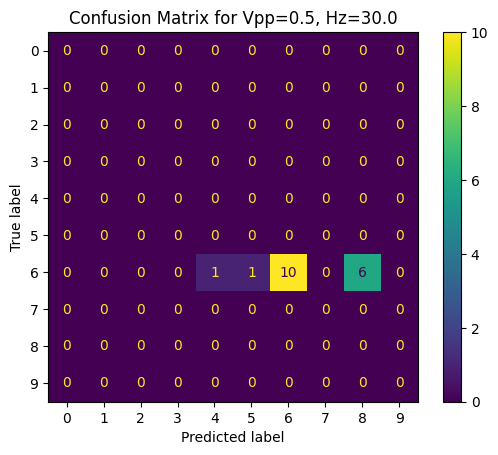

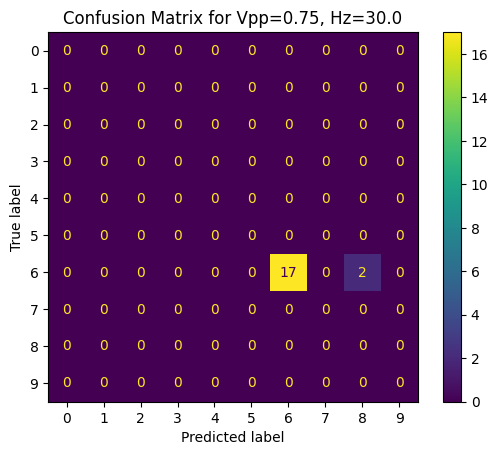

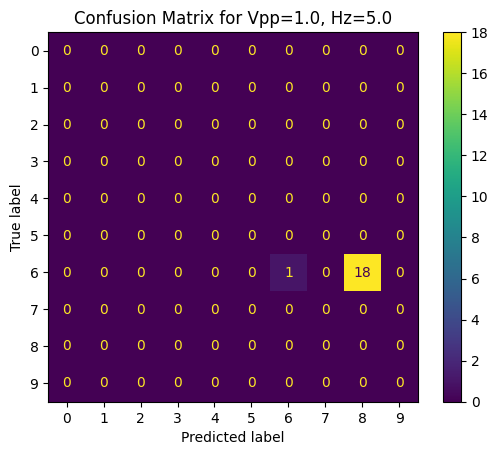

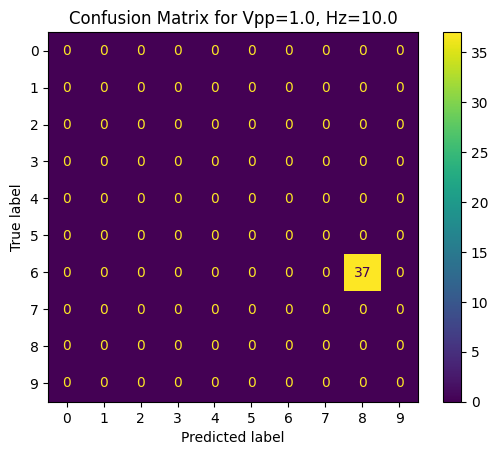

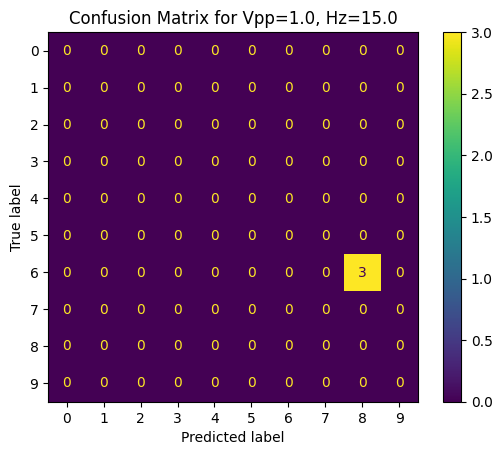

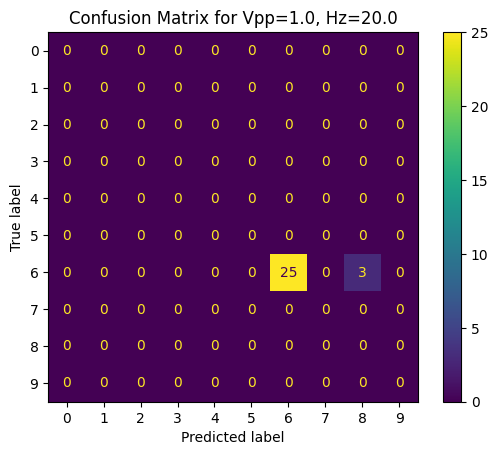

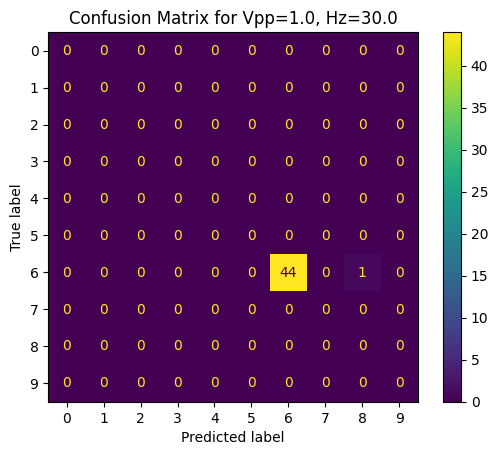

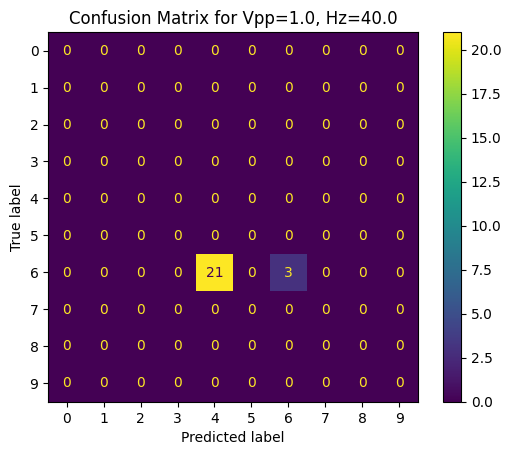

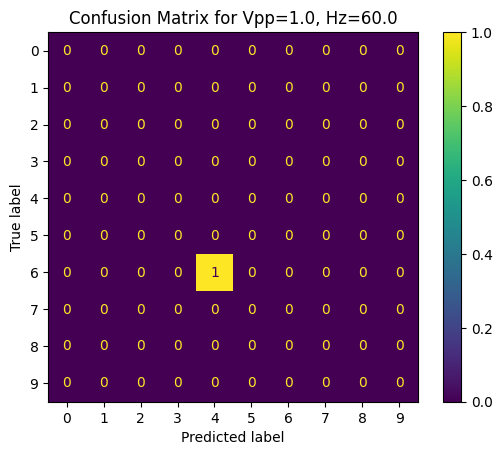

In [52]:
for (vpp, hz), group in results_df.groupby(['Vpp', 'Hz']):
    # Get actual and predicted classes for the group
    y_true_group = group['Actual_Class']
    y_pred_group = group['Predicted_Class']

    # Calculate confusion matrix
    cm = confusion_matrix(y_true_group, y_pred_group, labels=svm_model.classes_)

    # Display confusion matrix with title
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
    disp.plot()
    plt.title(f"Confusion Matrix for Vpp={vpp}, Hz={hz}")
    plt.show()

## NN

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import copy
import seaborn as sns

### Data loading

In [54]:
class MyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)  # Assuming labels are integers

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [55]:
# PARAMETERS
batch_size = 32
num_epochs = 20
learning_rate = 0.001
best_val_loss = float('inf')  # Initialize with a very high value
best_model_state_dict = None

In [56]:
# Create datasets and dataloaders
train_dataset = MyDataset(X_train_scaled, y_train)
val_dataset = MyDataset(X_val_scaled, y_val)
test_dataset = MyDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model creation

In [57]:
class MyModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

### Training

In [58]:
# Create model, optimizer, and loss function
input_size = X_train.shape[1]  # Number of input features
num_classes = len(y_train.unique())  # Number of output classes

model = MyModel(input_size, num_classes)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification

Epoch [1/20], Train Loss: 2.3020
Epoch [1/20], Validation Loss: 2.2914
Epoch [2/20], Train Loss: 2.2860
Epoch [2/20], Validation Loss: 2.2768
Epoch [3/20], Train Loss: 2.2677
Epoch [3/20], Validation Loss: 2.2513
Epoch [4/20], Train Loss: 2.2389
Epoch [4/20], Validation Loss: 2.2131
Epoch [5/20], Train Loss: 2.1874
Epoch [5/20], Validation Loss: 2.1506
Epoch [6/20], Train Loss: 2.1246
Epoch [6/20], Validation Loss: 2.0607
Epoch [7/20], Train Loss: 2.0287
Epoch [7/20], Validation Loss: 1.9413
Epoch [8/20], Train Loss: 1.9189
Epoch [8/20], Validation Loss: 1.8288
Epoch [9/20], Train Loss: 1.7947
Epoch [9/20], Validation Loss: 1.7047
Epoch [10/20], Train Loss: 1.6763
Epoch [10/20], Validation Loss: 1.5888
Epoch [11/20], Train Loss: 1.5631
Epoch [11/20], Validation Loss: 1.4750
Epoch [12/20], Train Loss: 1.4490
Epoch [12/20], Validation Loss: 1.3980
Epoch [13/20], Train Loss: 1.3595
Epoch [13/20], Validation Loss: 1.2759
Epoch [14/20], Train Loss: 1.2633
Epoch [14/20], Validation Loss: 1.1

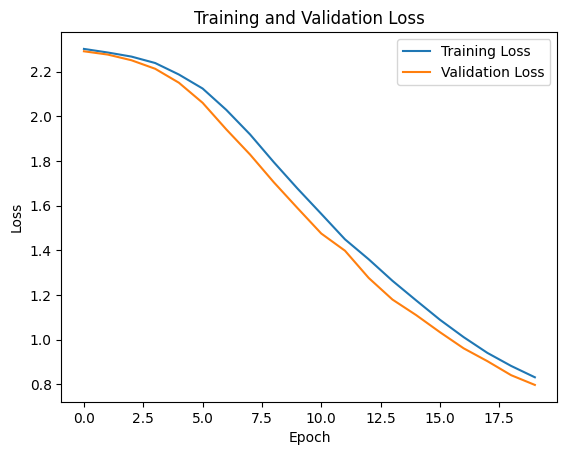

<All keys matched successfully>

In [59]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
  # Training loop
  epoch_train_loss = 0.0  # Accumulate loss for the epoch
  for batch_idx, (data, target) in enumerate(train_loader):
    # Forward pass
    output = model(data)
    loss = criterion(output, target)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_train_loss += loss.item()  # Add batch loss

    # Print progress (optional)
    '''
    if batch_idx % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    '''
  epoch_train_loss /= len(train_loader)  # Average training loss for the epoch
  train_losses.append(epoch_train_loss)  # Store training loss
  print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}")

  # Validation loop
  model.eval()
  with torch.no_grad():
    val_loss = 0.0
    for data, target in val_loader:
        output = model(data)
        loss = criterion(output, target)
        val_loss += loss.item()

    val_loss /= len(val_loader)  # Average validation loss

    # Check for improvement and save the best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state_dict = copy.deepcopy(model.state_dict())  # Save model state
        torch.save(best_model_state_dict, 'best_model.pth')  # Save to file

  val_losses.append(val_loss)  # Store validation loss
  print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}")

# Plot the losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Load the best model state
model.load_state_dict(torch.load('best_model.pth'))

### Evaluation

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       0.50      1.00      0.67        20
           4       1.00      1.00      1.00        18
           5       1.00      1.00      1.00        21
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      0.95      0.97        20

    accuracy                           0.89       199
   macro avg       0.85      0.89      0.86       199
weighted avg       0.84      0.89      0.86       199



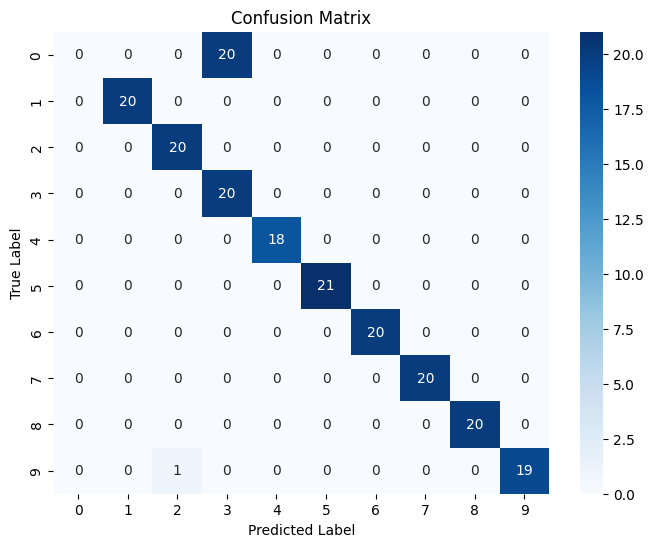

In [60]:
model.eval()

# Make predictions on the test set
y_pred = []
y_true = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        _, predicted = torch.max(output, 1)
        y_pred.extend(predicted.cpu().numpy())  # Convert to NumPy array
        y_true.extend(target.cpu().numpy())  # Convert to NumPy array

# Generate classification report
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(num_classes)]))

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[str(i) for i in range(num_classes)], yticklabels=[str(i) for i in range(num_classes)])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Test model

In [61]:
with torch.no_grad():
    predictions = model(torch.tensor(X_prueba_scaled.values, dtype=torch.float32))
    y_pred = torch.argmax(predictions, dim=1).numpy()
#y_pred = model.predict(X_prueba_scaled)
print(classification_report(y_prueba, y_pred, zero_division=0))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           6       1.00      0.13      0.22       245
           8       0.00      0.00      0.00         0

    accuracy                           0.13       245
   macro avg       0.25      0.03      0.06       245
weighted avg       1.00      0.13      0.22       245



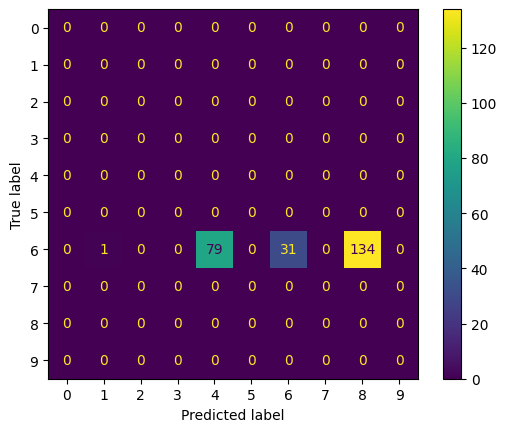

In [63]:
# Calculate confusion matrix
cm = confusion_matrix(y_prueba, y_pred, labels=[i for i in range(num_classes)])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(num_classes)])
disp.plot()
plt.show()

In [64]:
results_df = pd.DataFrame({'Vpp': labels_prueba['Vpp'],
                           'Hz': labels_prueba['Hz'],
                           'Actual_Class': y_prueba,
                           'Predicted_Class': y_pred})

In [65]:
# Group by 'Vpp' and 'Hz' and calculate accuracy
accuracy_by_vpp_hz = results_df.groupby(['Vpp', 'Hz'])['Actual_Class'].apply(lambda x: accuracy_score(x, results_df.loc[x.index, 'Predicted_Class']))

# Print the accuracy for each combination of 'Vpp' and 'Hz'
print(accuracy_by_vpp_hz)

# You can further analyze the results by looking at other metrics like precision, recall, etc.
# For example, to calculate precision for each group:
precision_by_vpp_hz = results_df.groupby(['Vpp', 'Hz'])['Actual_Class'].apply(lambda x: precision_score(x, results_df.loc[x.index, 'Predicted_Class'], average='weighted', zero_division=0))  # Use zero_division=0 to handle cases where a class is not predicted
print(precision_by_vpp_hz)

Vpp     Hz  
0.0625  30.0    0.000000
0.0650  30.0    0.000000
0.1250  30.0    0.000000
0.2500  30.0    0.000000
0.5000  30.0    0.000000
0.7500  30.0    0.000000
1.0000  5.0     0.000000
        10.0    0.000000
        15.0    1.000000
        20.0    0.857143
        30.0    0.088889
        40.0    0.000000
        60.0    0.000000
Name: Actual_Class, dtype: float64
Vpp     Hz  
0.0625  30.0    0.0
0.0650  30.0    0.0
0.1250  30.0    0.0
0.2500  30.0    0.0
0.5000  30.0    0.0
0.7500  30.0    0.0
1.0000  5.0     0.0
        10.0    0.0
        15.0    1.0
        20.0    1.0
        30.0    1.0
        40.0    0.0
        60.0    0.0
Name: Actual_Class, dtype: float64


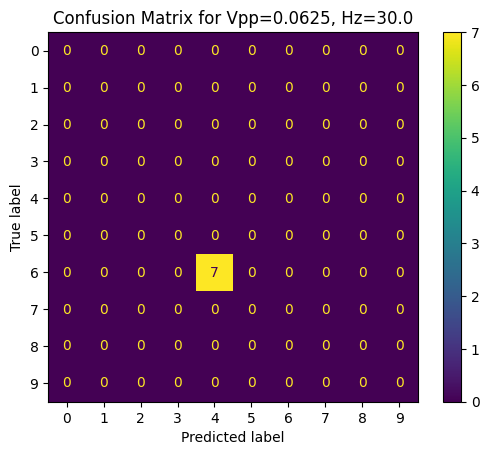

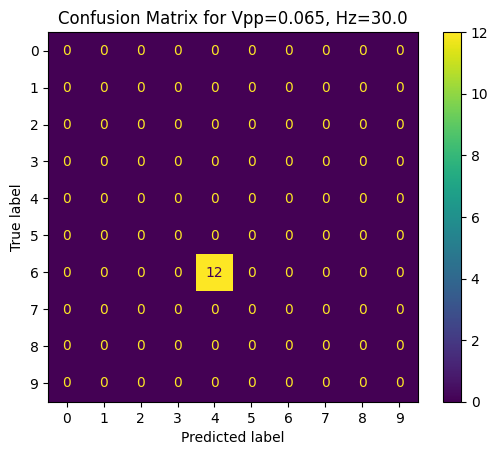

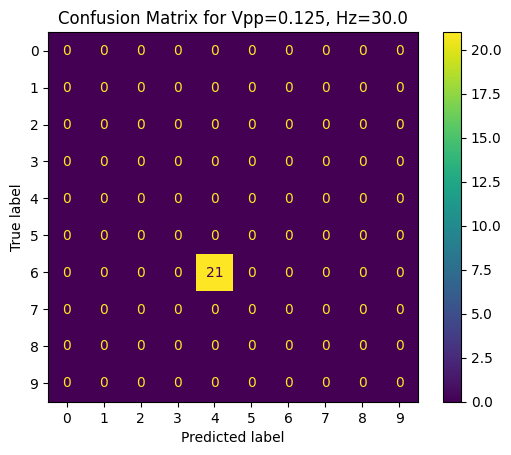

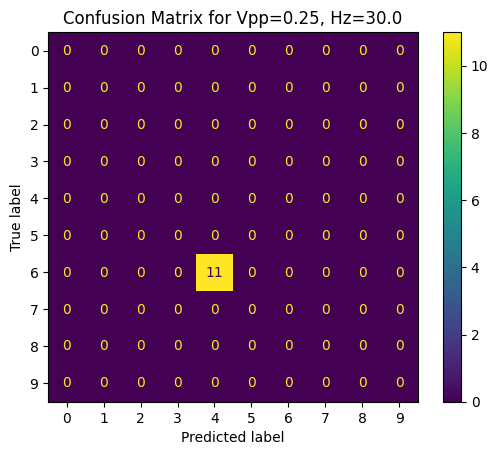

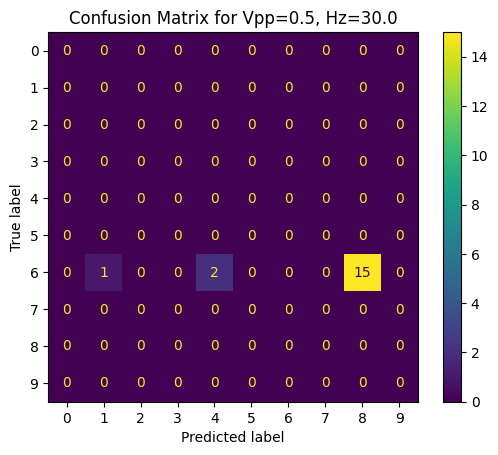

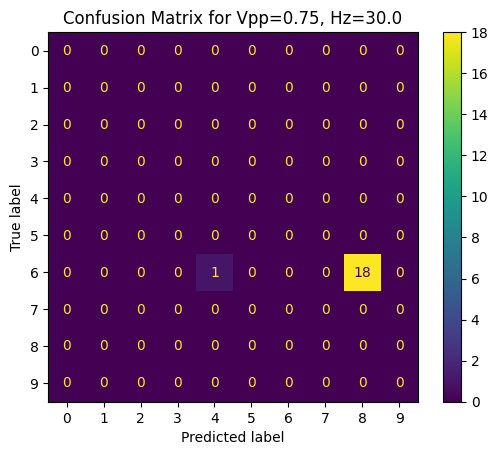

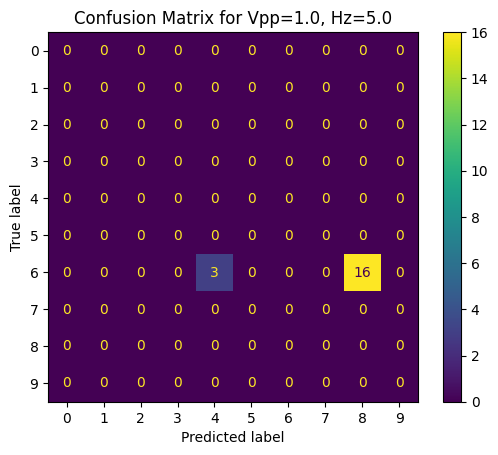

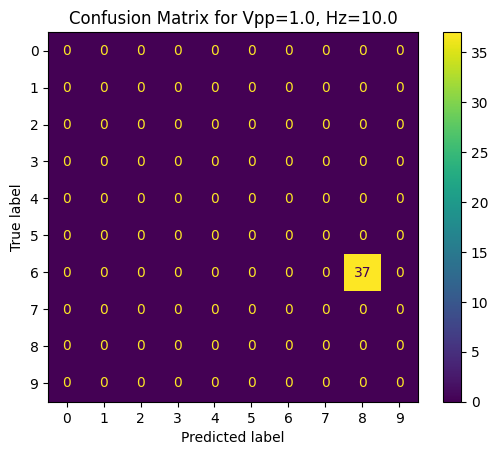

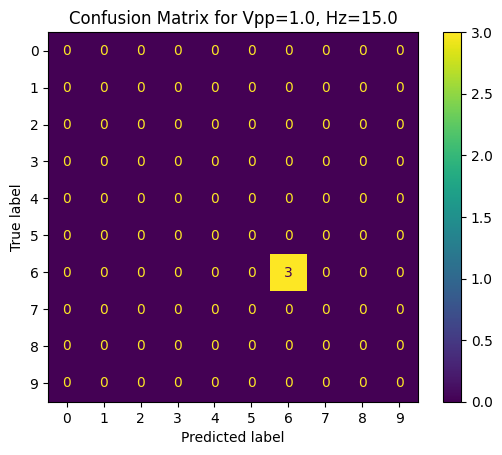

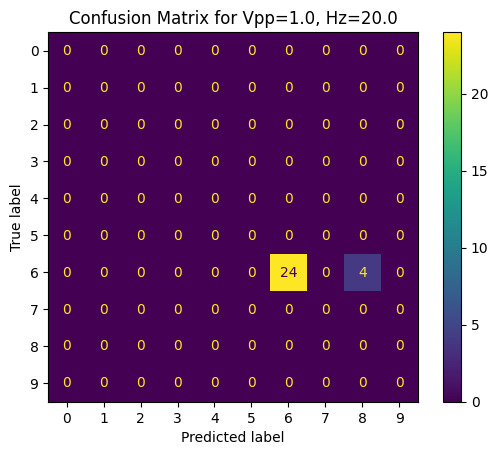

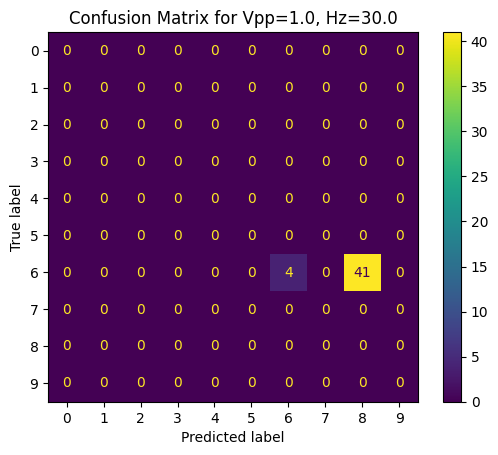

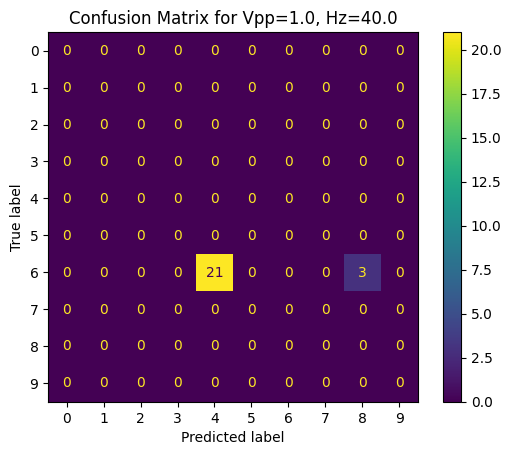

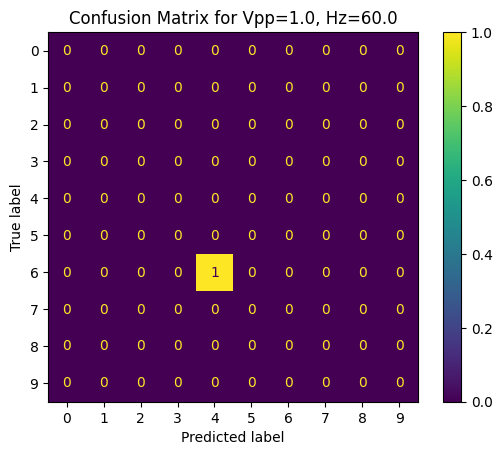

In [66]:
for (vpp, hz), group in results_df.groupby(['Vpp', 'Hz']):
    # Get actual and predicted classes for the group
    y_true_group = group['Actual_Class']
    y_pred_group = group['Predicted_Class']

    # Calculate confusion matrix
    cm = confusion_matrix(y_true_group, y_pred_group, labels=[i for i in range(num_classes)])

    # Display confusion matrix with title
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[str(i) for i in range(num_classes)])
    disp.plot()
    plt.title(f"Confusion Matrix for Vpp={vpp}, Hz={hz}")
    plt.show()